# Rveda Generated V2 GRPO Training Launcher

This notebook is the evolving Colab path for generated V2 training. It keeps the existing smoke launcher stable and focuses on:

1. syncing the repo,
2. generating V2 task JSONs,
3. preflighting live environment rollouts,
4. running a small-model GRPO training pass,
5. regenerating observability artifacts, and
6. exporting judge-readable evidence.

Start with the tiny 1.5B plain-TRL configuration before trying 7B runs.

## 1. Clone repo and install runtime dependencies

In [38]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

repo_root = Path(os.environ.get("RVEDA_REPO_ROOT", "/content/rveda"))
if not repo_root.exists():
    subprocess.check_call(["git", "clone", "https://github.com/anirudw/rveda.git", str(repo_root)])
os.chdir(repo_root)

%pip install -q --upgrade pip
%pip install -q -e .
%pip install -q datasets accelerate trl unsloth peft bitsandbytes pytest
print("Installed editable rveda plus datasets, accelerate, trl, unsloth, peft, bitsandbytes, pytest")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for openenv-rveda (pyproject.toml) ... done
Installed editable rveda plus datasets, accelerate, trl, unsloth, peft, bitsandbytes, pytest


## 2. Sync repo

By default this pulls `main`. Set `RVEDA_GIT_BRANCH` before running if you need a feature branch.

In [39]:
repo_root = Path(os.environ.get("RVEDA_REPO_ROOT", "/content/rveda"))
branch = os.environ.get("RVEDA_GIT_BRANCH", "main")

if not repo_root.exists():
    subprocess.check_call(["git", "clone", "https://github.com/anirudw/rveda.git", str(repo_root)])

os.chdir(repo_root)
subprocess.check_call(["git", "fetch", "origin", branch])
subprocess.check_call(["git", "checkout", branch])
subprocess.check_call(["git", "reset", "--hard", f"origin/{branch}"])

# Avoid stale imports after git sync in long-lived Colab kernels.
for name in list(sys.modules):
    if name.startswith(("train_grpo_smoke", "trl_bridge", "server.", "models", "generate_cases")):
        del sys.modules[name]

script_path = repo_root / "train_grpo_smoke.py"
print("Repo root:", repo_root)
print("Branch:", branch)
print(subprocess.check_output(["git", "log", "--oneline", "-3"], text=True))

Repo root: /content/rveda
Branch: main
156ac8e deeper type cleaning
6ad6fc3 type fix 2
c7e4f90 type correction



## 3. Verify local checks

Judges will care more about a rerunnable small-model path than a single oversized run. Keep the repo checks green before training.

In [40]:
pytest_result = subprocess.run([sys.executable, "-m", "pytest", "-q"], text=True, capture_output=True)
print(pytest_result.stdout or "<empty>")
print(pytest_result.stderr or "<empty>")
assert pytest_result.returncode == 0

openenv_result = subprocess.run(["openenv", "validate"], text=True, capture_output=True)
print(openenv_result.stdout or "<empty>")
print(openenv_result.stderr or "<empty>")
assert openenv_result.returncode == 0

...........................................                              [100%]
43 passed in 6.00s

<empty>
[OK] rveda: Ready for multi-mode deployment

<empty>


## 4. Generate deterministic V2 cases

In [41]:
result = subprocess.run(
    [
        sys.executable,
        "generate_cases.py",
        "--output-dir",
        "examples",
        "--seed",
        "7",
        "--clean",
    ],
    text=True,
    capture_output=True,
)
print(result.stdout)
print(result.stderr)
assert result.returncode == 0

manifest = json.loads(Path("examples/synthetic_cases_manifest.json").read_text())
print(json.dumps({
    "task_count": manifest["task_count"],
    "splits": manifest["splits"],
    "difficulties": manifest["difficulties"],
    "drift_enabled_count": manifest["drift_enabled_count"],
}, indent=2))
print("First task IDs:")
print("\n".join(manifest["task_ids"][:10]))

Wrote 12 synthetic V2 tasks to examples


{
  "task_count": 12,
  "splits": {
    "train": 6,
    "eval": 3,
    "smoke": 3
  },
  "difficulties": {
    "easy": 4,
    "medium": 4,
    "hard": 4
  },
  "drift_enabled_count": 5
}
First task IDs:
v2_task_train_easy_hypothyroid_unspecified_v1_001
v2_task_train_easy_overweight_counseling_v1_002
v2_task_train_medium_chest_pain_observation_v1_003
v2_task_train_medium_diabetes_hyperglycemia_drift_drift_004
v2_task_train_hard_diabetes_ckd_combo_drift_drift_005
v2_task_train_hard_morbid_obesity_policy_drift_drift_006
v2_task_eval_easy_hashimoto_confirmation_v1_007
v2_task_eval_medium_ckd_stage_three_v2_008
v2_task_eval_hard_acute_mi_drift_drift_009
v2_task_smoke_easy_hypothyroid_unspecified_v1_010


## 5. Preflight generated easy/medium/hard rollouts

Do not train until these complete with terminal `SUBMIT` and no final error.

In [42]:
from server.rveda_environment import RvedaEnvironment
from train_grpo_smoke import default_action_for_observation
from trl_bridge import RvedaTrainingBridge

env = RvedaEnvironment()
generated = [task for task in env._v2_tasks if task["task_id"].startswith("v2_task_")]
print("Loaded generated tasks:", len(generated))

for difficulty in ["easy", "medium", "hard"]:
    task_id = next(
        task["task_id"]
        for task in generated
        if task["split"] == "train" and task["difficulty"] == difficulty
    )
    with RvedaTrainingBridge() as bridge:
        trace = bridge.rollout(
            lambda prompt, obs: default_action_for_observation(obs, task_id),
            task_id=task_id,
            max_steps=10,
        )

    actions = [step.action["action_type"] for step in trace.steps if step.action]
    print("\n" + "=" * 80)
    print("task_id:", task_id)
    print("difficulty:", difficulty)
    print("total_reward:", trace.total_reward)
    print("done:", trace.done)
    print("actions:", actions)
    print("final_error:", trace.steps[-1].observation.last_error)
    assert trace.done, f"{task_id} did not finish"
    assert trace.steps[-1].observation.last_error is None, trace.steps[-1].observation.last_error
    assert actions[-1] == "SUBMIT", actions
    for required in ["QUERY_EHR", "SEARCH", "DETAILS", "CHECK_POLICY", "REASONING_LOG", "VALIDATE_CLAIM_SCHEMA", "SUBMIT"]:
        assert required in actions, (required, actions)

Loaded generated tasks: 12

task_id: v2_task_train_easy_hypothyroid_unspecified_v1_001
difficulty: easy
total_reward: 1.29
done: True
actions: ['QUERY_EHR', 'SEARCH', 'DETAILS', 'CHECK_POLICY', 'VALIDATE_CLAIM_SCHEMA', 'REASONING_LOG', 'SUBMIT']
final_error: None

task_id: v2_task_train_medium_chest_pain_observation_v1_003
difficulty: medium
total_reward: 1.3399999999999999
done: True
actions: ['QUERY_EHR', 'QUERY_EHR', 'SEARCH', 'DETAILS', 'CHECK_POLICY', 'VALIDATE_CLAIM_SCHEMA', 'REASONING_LOG', 'SUBMIT']
final_error: None

task_id: v2_task_train_hard_diabetes_ckd_combo_drift_drift_005
difficulty: hard
total_reward: 1.3399999999999999
done: True
actions: ['QUERY_EHR', 'QUERY_EHR', 'SEARCH', 'DETAILS', 'CHECK_POLICY', 'VALIDATE_CLAIM_SCHEMA', 'REASONING_LOG', 'SUBMIT']
final_error: None


## 6. Select generated training tasks

In [43]:
train_task_ids = [
    task["task_id"]
    for task in generated
    if task["split"] == "train" and task["difficulty"] in {"easy", "medium"}
][:6]
tiny_train_task_ids = [
    task["task_id"]
    for task in generated
    if task["split"] == "train" and task["difficulty"] == "easy"
][:2]
small_train_task_ids = [
    task["task_id"]
    for task in generated
    if task["split"] == "train" and task["difficulty"] in {"easy", "medium"}
][:4]

eval_task_ids = [task["task_id"] for task in generated if task["split"] == "eval"][:4]

print("TINY TRAIN TASKS")
print("\n".join(tiny_train_task_ids))
print("\nSMALL TRAIN TASKS")
print("\n".join(small_train_task_ids))
print("\nFULL TRAIN TASKS")
print("TRAIN TASKS")
print("\n".join(train_task_ids))
print("\nEVAL TASKS")
print("\n".join(eval_task_ids))

TINY TRAIN TASKS
v2_task_train_easy_hypothyroid_unspecified_v1_001
v2_task_train_easy_overweight_counseling_v1_002

SMALL TRAIN TASKS
v2_task_train_easy_hypothyroid_unspecified_v1_001
v2_task_train_easy_overweight_counseling_v1_002
v2_task_train_medium_chest_pain_observation_v1_003
v2_task_train_medium_diabetes_hyperglycemia_drift_drift_004

FULL TRAIN TASKS
TRAIN TASKS
v2_task_train_easy_hypothyroid_unspecified_v1_001
v2_task_train_easy_overweight_counseling_v1_002
v2_task_train_medium_chest_pain_observation_v1_003
v2_task_train_medium_diabetes_hyperglycemia_drift_drift_004

EVAL TASKS
v2_task_eval_easy_hashimoto_confirmation_v1_007
v2_task_eval_hard_acute_mi_drift_drift_009
v2_task_eval_medium_ckd_stage_three_v2_008


## 7. Run generated V2 small-model GRPO smoke training

In [44]:
print("Runtime preflight:")
try:
    gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.free", "--format=csv,noheader"],
        text=True,
        capture_output=True,
    )
    print(gpu.stdout.strip() or gpu.stderr.strip() or "nvidia-smi returned no output")
except FileNotFoundError:
    print("nvidia-smi not found; switch Colab to a GPU runtime before training.")

TRAIN_PRESET = "tiny_1p5b_plain_trl"
train_presets = {
    "tiny_1p5b_plain_trl": {
        "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
        "task_ids": tiny_train_task_ids,
        "samples_per_task": 1,
        "episodes": 1,
        "train_steps": 2,
        "max_episode_steps": 4,
        "max_new_tokens": 64,
        "disable_unsloth_fast_rl": True,
        "output_dir": Path("artifacts/grpo_generated_v2_tiny_1p5b"),
    },
    "small_1p5b_plain_trl": {
        "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
        "task_ids": small_train_task_ids,
        "samples_per_task": 1,
        "episodes": 1,
        "train_steps": 4,
        "max_episode_steps": 6,
        "max_new_tokens": 96,
        "disable_unsloth_fast_rl": True,
        "output_dir": Path("artifacts/grpo_generated_v2_small_1p5b"),
    },
    "standard_7b": {
        "model_name": "Qwen/Qwen2.5-7B-Instruct",
        "task_ids": train_task_ids,
        "samples_per_task": 2,
        "episodes": 1,
        "train_steps": 20,
        "max_episode_steps": 10,
        "max_new_tokens": 128,
        "disable_unsloth_fast_rl": False,
        "output_dir": Path("artifacts/grpo_generated_v2_7b_smoke"),
    },
}
config = train_presets[TRAIN_PRESET]
output_dir = config["output_dir"]
command = [
    sys.executable,
    str(script_path),
    "--model-name",
    config["model_name"],
    "--output-dir",
    str(output_dir),
    "--task-ids",
    *config["task_ids"],
    "--samples-per-task",
    str(config["samples_per_task"]),
    "--episodes",
    str(config["episodes"]),
    "--train-steps",
    str(config["train_steps"]),
    "--max-episode-steps",
    str(config["max_episode_steps"]),
    "--max-new-tokens",
    str(config["max_new_tokens"]),
]
if config["disable_unsloth_fast_rl"]:
    command.append("--disable-unsloth-fast-rl")
print("Preset:", TRAIN_PRESET)
print("Running:", " ".join(command))
result = subprocess.run(command, text=True, capture_output=True)
print("\n--- stdout ---")
print(result.stdout or "<empty>")
print("\n--- stderr ---")
print(result.stderr or "<empty>")
assert result.returncode == 0

Runtime preflight:
Tesla T4, 15360 MiB, 14913 MiB
Preset: tiny_1p5b_plain_trl
Running: /usr/bin/python3 /content/rveda/train_grpo_smoke.py --model-name Qwen/Qwen2.5-1.5B-Instruct --output-dir artifacts/grpo_generated_v2_tiny_1p5b --task-ids v2_task_train_easy_hypothyroid_unspecified_v1_001 v2_task_train_easy_overweight_counseling_v1_002 --samples-per-task 1 --episodes 1 --train-steps 2 --max-episode-steps 4 --max-new-tokens 64 --disable-unsloth-fast-rl

--- stdout ---
{'loss': 0.0, 'grad_norm': 0.0, 'learning_rate': 1e-06, 'num_tokens': 892.0, 'completions/mean_length': 64.0, 'completions/min_length': 64.0, 'completions/max_length': 64.0, 'completions/clipped_ratio': 1.0, 'completions/mean_terminated_length': 0.0, 'completions/min_terminated_length': 0.0, 'completions/max_terminated_length': 0.0, 'rewards/reward_func/mean': 0.11999999731779099, 'rewards/reward_func/std': 0.0, 'reward': 0.11999999731779099, 'reward_std': 0.0, 'frac_reward_zero_std': 1.0, 'entropy': 2.5271289348602295, '

## 8. Inspect observability artifacts

In [45]:
obs_command = [
    sys.executable,
    str(script_path),
    "--output-dir",
    str(output_dir),
    "--emit-observability-only",
]
obs_result = subprocess.run(obs_command, text=True, capture_output=True)
print(obs_result.stdout or "<empty>")
if obs_result.returncode != 0:
    print(obs_result.stderr or "<empty>")
assert obs_result.returncode == 0

required = [
    "command_metadata.json",
    "scripted_baseline.json",
    "train_rows_preview.json",
    "baseline_model_eval.json",
    "post_train_model_eval.json",
    "trainer_log_history.json",
    "summary.json",
    "baseline_vs_trained_comparison.json",
    "loss_plot.svg",
    "reward_plot.svg",
    "verifier_metrics_plot.svg",
]
for name in required:
    path = output_dir / name
    print(name, path.exists(), path.stat().st_size if path.exists() else None)
    assert path.exists(), name

summary = json.loads((output_dir / "summary.json").read_text())
print(json.dumps({
    "model_name": summary.get("model_name"),
    "train_steps": summary.get("train_steps"),
    "train_rows": summary.get("train_rows"),
    "baseline_mean_total_reward": summary.get("baseline_mean_total_reward"),
    "post_train_mean_total_reward": summary.get("post_train_mean_total_reward"),
}, indent=2))

{
  "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
  "smoke_model": null,
  "task_ids": [
    "v2_task_train_easy_hypothyroid_unspecified_v1_001",
    "v2_task_train_easy_overweight_counseling_v1_002"
  ],
  "train_steps": 2,
  "interpretation": "Smoke observability artifact. Equal baseline/trained rewards indicate pipeline proof, not meaningful learning.",
  "baseline_policy": {
    "episode_count": 2,
    "mean_total_reward": 0.18075000000000002,
    "total_rewards": [
      0.1615,
      0.2
    ],
    "action_counts": {
      "SEARCH": 2,
      "DETAILS": 2,
      "SUBMIT": 0,
      "QUERY_EHR": 3
    },
    "search_to_submission_ratio": null,
    "timeout_frequency": 0.0,
    "grounding_f1": 0.8,
    "grounding_f1_note": "Proxy from v2_verifier_snapshot.grounding_proxy; true precision/recall labels are not emitted by this smoke runner.",
    "drift_adaptation_rate": null,
    "drift_adaptation_rate_note": "Unavailable: current smoke task has drift disabled and emits no drift adaptati

## 9. View plots

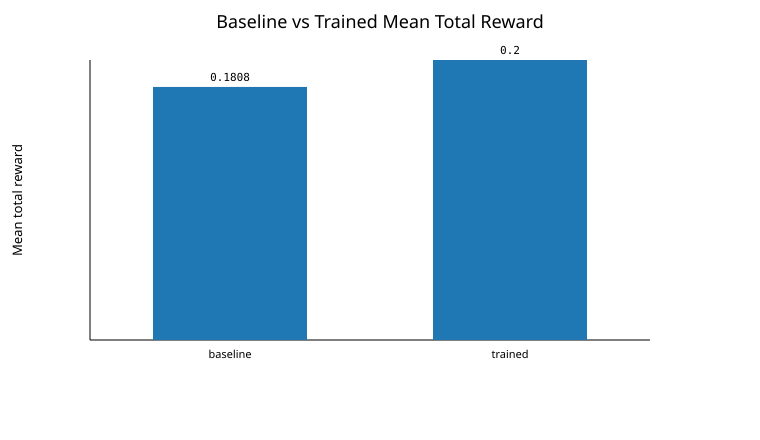

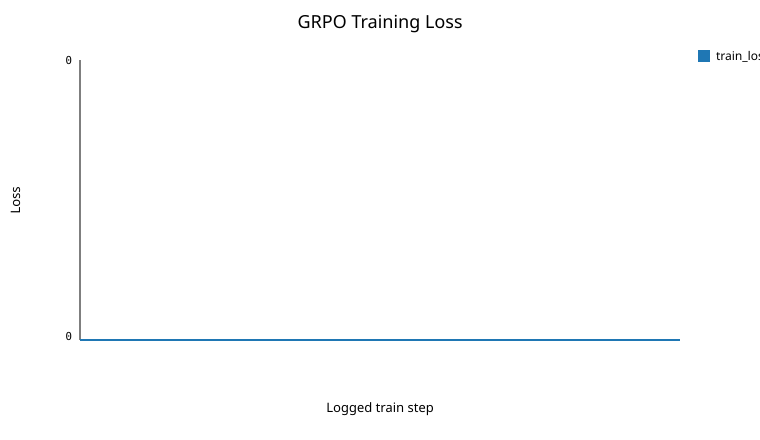

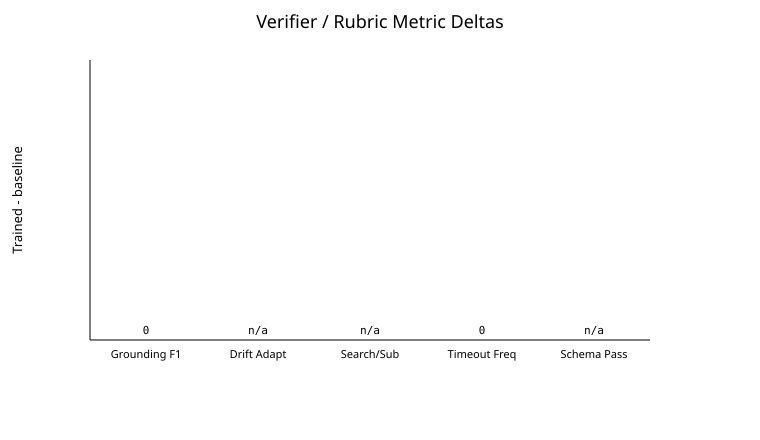

In [46]:
from IPython.display import SVG, display

display(SVG(filename=str(output_dir / "reward_plot.svg")))
display(SVG(filename=str(output_dir / "loss_plot.svg")))
display(SVG(filename=str(output_dir / "verifier_metrics_plot.svg")))

## 10. Export artifacts

In [47]:
archive_path = shutil.make_archive("/content/grpo_generated_v2_7b_smoke_artifacts", "zip", output_dir)
print("Archive:", archive_path)
try:
    from google.colab import files
    files.download(archive_path)
except Exception as exc:
    print("Download unavailable outside Colab:", exc)

Archive: /content/grpo_generated_v2_7b_smoke_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Phase 2

## Config
### Increasing step counts so the model reaches submit

In [51]:
TRAIN_PRESET = "small_1p5b_plain_trl"
train_presets["small_1p5b_plain_trl"]["max_episode_steps"] = 8
train_presets["small_1p5b_plain_trl"]["train_steps"] = 4
train_presets["small_1p5b_plain_trl"]["output_dir"] = Path("artifacts/grpo_generated_v2_small_1p5b_submit_check")

config = train_presets[TRAIN_PRESET]
output_dir = config["output_dir"]
print(TRAIN_PRESET)
print(config)

small_1p5b_plain_trl
{'model_name': 'Qwen/Qwen2.5-1.5B-Instruct', 'task_ids': ['v2_task_train_easy_hypothyroid_unspecified_v1_001', 'v2_task_train_easy_overweight_counseling_v1_002', 'v2_task_train_medium_chest_pain_observation_v1_003', 'v2_task_train_medium_diabetes_hyperglycemia_drift_drift_004'], 'samples_per_task': 1, 'episodes': 1, 'train_steps': 4, 'max_episode_steps': 8, 'max_new_tokens': 96, 'disable_unsloth_fast_rl': True, 'output_dir': PosixPath('artifacts/grpo_generated_v2_small_1p5b_submit_check')}


## Phase 2 Run

In [52]:
print("Runtime preflight:")
try:
    gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.free", "--format=csv,noheader"],
        text=True,
        capture_output=True,
    )
    print(gpu.stdout.strip() or gpu.stderr.strip() or "nvidia-smi returned no output")
except FileNotFoundError:
    print("nvidia-smi not found; switch Colab to a GPU runtime before training.")

command = [
    sys.executable,
    str(script_path),
    "--model-name",
    config["model_name"],
    "--output-dir",
    str(output_dir),
    "--task-ids",
    *config["task_ids"],
    "--samples-per-task",
    str(config["samples_per_task"]),
    "--episodes",
    str(config["episodes"]),
    "--train-steps",
    str(config["train_steps"]),
    "--max-episode-steps",
    str(config["max_episode_steps"]),
    "--max-new-tokens",
    str(config["max_new_tokens"]),
]
if config["disable_unsloth_fast_rl"]:
    command.append("--disable-unsloth-fast-rl")

print("Preset:", TRAIN_PRESET)
print("Running:", " ".join(command))
result = subprocess.run(command, text=True, capture_output=True)
print("\n--- stdout ---")
print(result.stdout or "<empty>")
print("\n--- stderr ---")
print(result.stderr or "<empty>")
assert result.returncode == 0

Runtime preflight:
Tesla T4, 15360 MiB, 14913 MiB
Preset: small_1p5b_plain_trl
Running: /usr/bin/python3 /content/rveda/train_grpo_smoke.py --model-name Qwen/Qwen2.5-1.5B-Instruct --output-dir artifacts/grpo_generated_v2_small_1p5b_submit_check --task-ids v2_task_train_easy_hypothyroid_unspecified_v1_001 v2_task_train_easy_overweight_counseling_v1_002 v2_task_train_medium_chest_pain_observation_v1_003 v2_task_train_medium_diabetes_hyperglycemia_drift_drift_004 --samples-per-task 1 --episodes 1 --train-steps 4 --max-episode-steps 8 --max-new-tokens 96 --disable-unsloth-fast-rl

--- stdout ---
{'loss': 0.0, 'grad_norm': 0.0, 'learning_rate': 1e-06, 'num_tokens': 940.0, 'completions/mean_length': 96.0, 'completions/min_length': 96.0, 'completions/max_length': 96.0, 'completions/clipped_ratio': 1.0, 'completions/mean_terminated_length': 0.0, 'completions/min_terminated_length': 0.0, 'completions/max_terminated_length': 0.0, 'rewards/reward_func/mean': 0.11999999731779099, 'rewards/reward_f

## Observability


In [54]:
obs_command = [
    sys.executable,
    str(script_path),
    "--output-dir",
    str(output_dir),
    "--emit-observability-only",
]
obs_result = subprocess.run(obs_command, text=True, capture_output=True)
print(obs_result.stdout or "<empty>")
if obs_result.returncode != 0:
    print(obs_result.stderr or "<empty>")
assert obs_result.returncode == 0

{
  "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
  "smoke_model": null,
  "task_ids": [
    "v2_task_train_easy_hypothyroid_unspecified_v1_001",
    "v2_task_train_easy_overweight_counseling_v1_002",
    "v2_task_train_medium_chest_pain_observation_v1_003",
    "v2_task_train_medium_diabetes_hyperglycemia_drift_drift_004"
  ],
  "train_steps": 4,
  "interpretation": "Smoke observability artifact. Equal baseline/trained rewards indicate pipeline proof, not meaningful learning.",
  "baseline_policy": {
    "episode_count": 4,
    "mean_total_reward": 1.32375,
    "total_rewards": [
      1.325,
      1.29,
      1.3399999999999999,
      1.3399999999999999
    ],
    "action_counts": {
      "SEARCH": 4,
      "DETAILS": 4,
      "SUBMIT": 4,
      "QUERY_EHR": 6
    },
    "search_to_submission_ratio": 1.0,
    "timeout_frequency": 0.0,
    "grounding_f1": 0.8857142857142857,
    "grounding_f1_note": "Proxy from v2_verifier_snapshot.grounding_proxy; true precision/recall labels are not e

## Inspect the artifacts:

In [55]:
required = [
    "command_metadata.json",
    "scripted_baseline.json",
    "train_rows_preview.json",
    "baseline_model_eval.json",
    "post_train_model_eval.json",
    "trainer_log_history.json",
    "summary.json",
    "baseline_vs_trained_comparison.json",
    "loss_plot.svg",
    "reward_plot.svg",
    "verifier_metrics_plot.svg",
]
for name in required:
    path = output_dir / name
    print(name, path.exists(), path.stat().st_size if path.exists() else None)
    assert path.exists(), name

command_metadata.json True 1684
scripted_baseline.json True 323031
train_rows_preview.json True 6311
baseline_model_eval.json True 332546
post_train_model_eval.json True 323030
trainer_log_history.json True 3443
summary.json True 1017
baseline_vs_trained_comparison.json True 5387
loss_plot.svg True 1059
reward_plot.svg True 1081
verifier_metrics_plot.svg True 1911


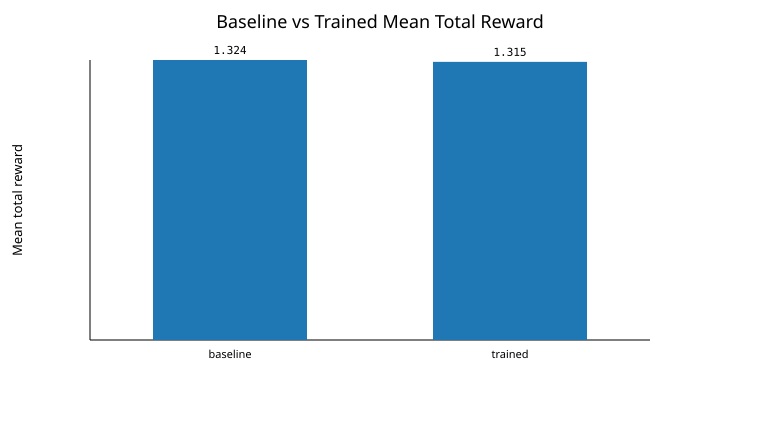

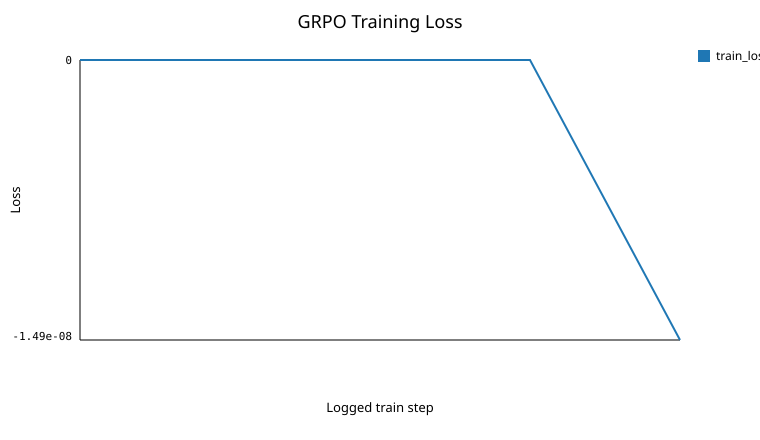

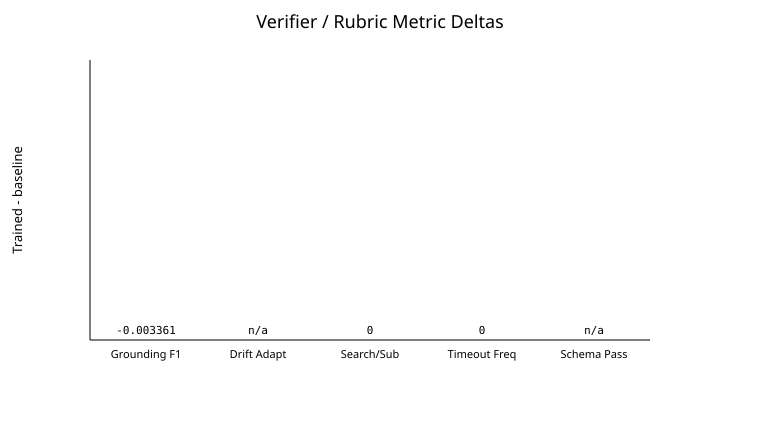

In [56]:
from IPython.display import SVG, display

display(SVG(filename=str(output_dir / "reward_plot.svg")))
display(SVG(filename=str(output_dir / "loss_plot.svg")))
display(SVG(filename=str(output_dir / "verifier_metrics_plot.svg")))

## PNG Convertion

In [58]:
%pip install -q cairosvg pillow

In [59]:
from pathlib import Path
import cairosvg

plot_src_dir = output_dir
plot_dst_dir = Path("docs/plots")
plot_dst_dir.mkdir(parents=True, exist_ok=True)

plot_map = {
    "reward_plot.svg": "reward_plot.png",
    "loss_plot.svg": "loss_plot.png",
    "verifier_metrics_plot.svg": "verifier_metrics_plot.png",
}

for src_name, dst_name in plot_map.items():
    src = plot_src_dir / src_name
    dst = plot_dst_dir / dst_name
    cairosvg.svg2png(url=str(src), write_to=str(dst))
    print(dst, dst.exists(), dst.stat().st_size if dst.exists() else None)

docs/plots/reward_plot.png True 10129
docs/plots/loss_plot.png True 13311
docs/plots/verifier_metrics_plot.png True 11785
